In [2]:
pip install tqdm

Note: you may need to restart the kernel to use updated packages.


Starting PPO training...


  7%|▋         | 10/150 [00:07<01:50,  1.27it/s]

Epoch 10/150 [7.9s] - Avg reward: 0.2288, Avg fidelity: 0.2288, Max fidelity: 0.6849, Best overall: 0.7093


 13%|█▎        | 20/150 [00:15<01:42,  1.27it/s]

Epoch 20/150 [15.7s] - Avg reward: 0.2359, Avg fidelity: 0.2359, Max fidelity: 0.6868, Best overall: 0.7279


...

Epoch 50/150 [40.4s] - Avg reward: 0.2046, Avg fidelity: 0.2046, Max fidelity: 0.7122, Best overall: 0.7279


 34%|███▍      | 51/150 [00:42<01:22,  1.21it/s]

Early stopping at epoch 52 due to no improvement for 15 epochs

Fine-tuning ensemble members...

Fine-tuning ensemble member 1/5
Initial fidelity: 0.653339



c:\Users\pp700\miniconda3\envs\reinforce\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Fine-tuning iter 50/500, fidelity: 0.835466, best: 0.835466
Fine-tuning iter 100/500, fidelity: 0.878541, best: 0.878541
Fine-tuning iter 150/500, fidelity: 0.942626, best: 0.942626
Fine-tuning iter 200/500, fidelity: 0.964016, best: 0.964016
Fine-tuning iter 250/500, fidelity: 0.965175, best: 0.965175
Fine-tuning iter 300/500, fidelity: 0.965195, best: 0.965195
Fine-tuning iter 350/500, fidelity: 0.965195, best: 0.965195
Fine-tuning iter 400/500, fidelity: 0.965195, best: 0.965195
Ensemble member 1 fine-tuned: 0.653339 → 0.965195

Fine-tuning ensemble member 2/5
Initial fidelity: 0.675774
Fine-tuning iter 50/500, fidelity: 0.811142, best: 0.811142
Fine-tuning iter 100/500, fidelity: 0.857012, best: 0.857012
Fine-tuning iter 150/500, fidelity: 0.923618, best: 0.923618
Fine-tuning iter 200/500, fidelity: 0.959086, best: 0.959086
Fine-tuning iter 250/500, fidelity: 0.964187, best: 0.964187
Fine-tuning iter 300/500, fidelity: 0.965369, best: 0.965369
Fine-tuning iter 350/500, fidelity: 0.

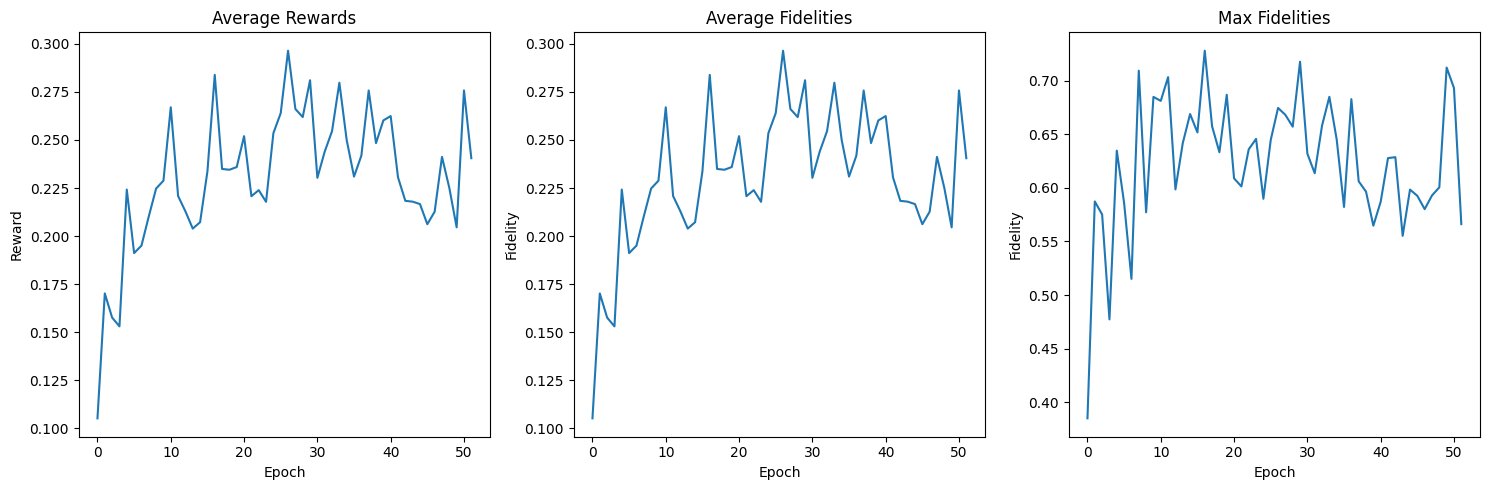


Final Results:
Best fidelity achieved: 0.999999

Best parameters found:
[2.62504   0.6695538 1.7130821 1.0561004 0.9820924 1.9624739 2.4016674
 1.3086461 1.7709646 0.9634397 1.0413027 1.340507  2.393123  0.9018514
 1.4846368 1.9521656 1.9190943 2.576911  1.7487444 1.2934716 0.8296325
 2.2742703 2.581798  2.5563552 0.        2.5911179 0.6722143 1.0708166
 0.        0.7447851]


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from qiskit_aer import Aer
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, state_fidelity
from tqdm import tqdm
import time
from qiskit import quantum_info
import random
from torch.optim.lr_scheduler import CosineAnnealingLR

# Constants - aligned with document
QBITS=3
NUM_PARAMS = 30
GAMMA = 0.99
GAE_LAMBDA = 0.95
EPS_CLIP = 0.2
LR_POLICY = 3e-4
LR_VALUE = 1e-3
ENTROPY_COEF = 0.01
NUM_AGENTS = 20
BATCH_SIZE = 320
INNER_EPOCHS = 5
MINIBATCH_SIZE = 32
TOTAL_EPOCHS = 150
ACTION_SCALE = 0.1
PATIENCE = 15
ENSEMBLE_SIZE = 5

# Target quantum state (|000...0>)
# target_state = Statevector.from_label('000')
target_state = quantum_info.random_statevector(2 ** QBITS)

def build_circuit(params):
    circuit = QuantumCircuit(3)
    circuit.u(params[0], params[1], params[2], 0)
    circuit.u(params[3], params[4], params[5], 1)
    circuit.rxx(params[6], 0, 1)
    circuit.u(params[7], params[8], params[9], 0)
    circuit.u(params[10], params[11], params[12], 2)
    circuit.rxx(params[13], 0, 2)
    circuit.u(params[14], params[15], params[16], 1)
    circuit.u(params[17], params[18], params[19], 2)
    circuit.rxx(params[20], 1, 2)
    circuit.u(params[21], params[22], params[23], 0)
    circuit.u(params[24], params[25], params[26], 1)
    circuit.u(params[27], params[28], params[29], 2)
    return circuit

def evaluate_fidelity(params):
    circuit = build_circuit(params)
    sv = Statevector.from_instruction(circuit)
    return state_fidelity(target_state, sv)

class PolicyNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(NUM_PARAMS, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh()
        )
        self.mean = nn.Linear(128, NUM_PARAMS)
        self.log_std = nn.Parameter(torch.ones(NUM_PARAMS) * -1.6)

        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.orthogonal_(layer.weight, gain=np.sqrt(2))
                nn.init.constant_(layer.bias, 0.0)
        nn.init.orthogonal_(self.mean.weight, gain=0.01)
        nn.init.constant_(self.mean.bias, 0.0)

    def forward(self, state):
        x = self.net(state)
        return self.mean(x), self.log_std.exp()

class ValueNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(NUM_PARAMS, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.orthogonal_(layer.weight, gain=np.sqrt(2))
                nn.init.constant_(layer.bias, 0.0)

    def forward(self, state):
        return self.net(state).squeeze()

class ExperienceMemory:
    def __init__(self, capacity=1000):
        self.capacity = capacity
        self.memory = []
        self.position = 0

    def push(self, state, action, reward, next_state, log_prob, value, fidelity):
        if len(self.memory) < self.capacity:
            self.memory.append(None)
        self.memory[self.position] = (state, action, reward, next_state, log_prob, value, fidelity)
        self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size):
        return zip(*random.sample(self.memory, batch_size))

    def __len__(self):
        return len(self.memory)

def normalize_states(states):
    return (states - np.pi) / np.pi

def calculate_reward(fidelity):
    return fidelity

def collect_trajectories(policy_net, value_net, epoch, memory=None):
    states, actions, rewards, values, log_probs, fidelities = [], [], [], [], [], []

    num_narrow_agents = int(NUM_AGENTS * 0.7)
    agent_states = []
    for _ in range(num_narrow_agents):
        agent_states.append(torch.rand(NUM_PARAMS) * 0.2)
    for _ in range(NUM_AGENTS - num_narrow_agents):
        agent_states.append(torch.rand(NUM_PARAMS) * np.pi)

  

    for agent_idx in range(NUM_AGENTS):
        state = agent_states[agent_idx]
        for _ in range(BATCH_SIZE // NUM_AGENTS):
            with torch.no_grad():
                state_norm = normalize_states(state)
                mean, std = policy_net(state_norm)
                dist = torch.distributions.Normal(mean, std)
                action = dist.sample()
                action = torch.clamp(action, -ACTION_SCALE, ACTION_SCALE)
                log_prob = dist.log_prob(action).sum().item()
                next_state = torch.clamp(state + action, 0, 2 * np.pi)

                fidelity = evaluate_fidelity(next_state.detach().numpy())
                reward = calculate_reward(fidelity)
                
                value = value_net(state_norm).item()

            states.append(state.clone())
            actions.append(action.clone())
            rewards.append(reward)
            values.append(value)
            log_probs.append(log_prob)
            fidelities.append(fidelity)

            if memory is not None and fidelity > 0.5:
                memory.push(state.clone(), action.clone(), reward, next_state.clone(),
                            log_prob, value, fidelity)

            state = next_state.clone()

    return states, actions, rewards, values, log_probs, fidelities, agent_states[-1]

def update_networks(policy_net, value_net, states, actions, rewards, values, log_probs_old,
                   optimizer_policy, optimizer_value):
    states_tensor = torch.stack(states)
    actions_tensor = torch.stack(actions)
    log_probs_old_tensor = torch.tensor(log_probs_old, dtype=torch.float32)

    returns, advantages = [], []
    gae = 0
    values = values + [value_net(normalize_states(states[-1])).item()]
    for t in reversed(range(len(rewards))):
        delta = rewards[t] + GAMMA * values[t + 1] - values[t]
        gae = delta + GAMMA * GAE_LAMBDA * gae
        returns.insert(0, gae + values[t])
        advantages.insert(0, gae)

    returns_tensor = torch.tensor(returns, dtype=torch.float32)
    advantages_tensor = torch.tensor(advantages, dtype=torch.float32)
    advantages_tensor = (advantages_tensor - advantages_tensor.mean()) / (advantages_tensor.std() + 1e-8)

    dataset_size = len(states)

    for _ in range(INNER_EPOCHS):
        indices = np.random.permutation(dataset_size)
        for start_idx in range(0, dataset_size, MINIBATCH_SIZE):
            end_idx = min(start_idx + MINIBATCH_SIZE, dataset_size)
            idx = indices[start_idx:end_idx]

            batch_states = states_tensor[idx]
            batch_states_norm = normalize_states(batch_states)
            batch_actions = actions_tensor[idx]
            batch_returns = returns_tensor[idx]
            batch_advantages = advantages_tensor[idx]
            batch_log_probs_old = log_probs_old_tensor[idx]

            mean, std = policy_net(batch_states_norm)
            dist = torch.distributions.Normal(mean, std)
            log_probs = dist.log_prob(batch_actions).sum(dim=1)
            entropy = dist.entropy().mean()
            ratio = torch.exp(log_probs - batch_log_probs_old)
            surrogate1 = ratio * batch_advantages
            surrogate2 = torch.clamp(ratio, 1 - EPS_CLIP, 1 + EPS_CLIP) * batch_advantages
            policy_loss = -torch.min(surrogate1, surrogate2).mean() - ENTROPY_COEF * entropy

            optimizer_policy.zero_grad()
            policy_loss.backward()
            torch.nn.utils.clip_grad_norm_(policy_net.parameters(), max_norm=0.5)
            optimizer_policy.step()

            value_preds = value_net(batch_states_norm)
            value_loss = nn.MSELoss()(value_preds, batch_returns)

            optimizer_value.zero_grad()
            value_loss.backward()
            torch.nn.utils.clip_grad_norm_(value_net.parameters(), max_norm=0.5)
            optimizer_value.step()

def fine_tune_parameters(params, iterations=500, lr=5e-3):
    params = params.detach().clone().requires_grad_(False)
    optimizer = optim.Adam([params], lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=20, verbose=False)

    best_fidelity = evaluate_fidelity(params.detach().numpy())
    best_params = params.detach().clone()
    no_improve = 0

    for i in range(iterations):
        optimizer.zero_grad()

        fidelity = evaluate_fidelity(params.detach().numpy())

        if fidelity > best_fidelity:
            best_fidelity = fidelity
            best_params = params.detach().clone()
            no_improve = 0
        else:
            no_improve += 1

        if no_improve > 50:
            break

        eps = 1e-5
        param_grad = torch.zeros_like(params)
        for j in range(len(params)):
            perturbed_params = params.detach().numpy().copy()
            perturbed_params[j] += eps
            fidelity_plus = evaluate_fidelity(perturbed_params)
            param_grad[j] = (fidelity_plus - fidelity) / eps  # One-sided difference

        params.grad = -param_grad

        if i % 10 == 0:
            params.grad += torch.randn_like(params.grad) * 0.01 * optimizer.param_groups[0]['lr']

        torch.nn.utils.clip_grad_norm_([params], max_norm=1.0)
        optimizer.step()
        with torch.no_grad():
            params.clamp_(0, 2 * np.pi)

        if (i + 1) % 50 == 0:
            print(f"Fine-tuning iter {i+1}/{iterations}, fidelity: {fidelity:.6f}, best: {best_fidelity:.6f}")

    return best_params

def main():
    torch.manual_seed(42)
    np.random.seed(42)
    random.seed(42)

    policy_net = PolicyNetwork()
    value_net = ValueNetwork()
    optimizer_policy = optim.Adam(policy_net.parameters(), lr=LR_POLICY)
    optimizer_value = optim.Adam(value_net.parameters(), lr=LR_VALUE)
    memory = ExperienceMemory(capacity=5000)

    scheduler_policy = CosineAnnealingLR(optimizer_policy, T_max=TOTAL_EPOCHS, eta_min=LR_POLICY/10)
    scheduler_value = CosineAnnealingLR(optimizer_value, T_max=TOTAL_EPOCHS, eta_min=LR_VALUE/10)

    avg_rewards_history = []
    avg_fidelities_history = []
    max_fidelities_history = []
    ensemble_parameters = []
    best_fidelity_overall = -float('inf')

    best_avg_fidelity = -float('inf')
    no_improvement_epochs = 0
    last_state = None

    print("Starting PPO training...")
    start_time = time.time()

    for epoch in tqdm(range(TOTAL_EPOCHS)):
        states, actions, rewards, values, log_probs, fidelities, last_state = collect_trajectories(
            policy_net, value_net, epoch, memory)

        update_networks(policy_net, value_net, states, actions, rewards, values, log_probs,
                        optimizer_policy, optimizer_value)

        scheduler_policy.step()
        scheduler_value.step()

        avg_reward = np.mean(rewards)
        avg_fidelity = np.mean(fidelities)
        max_fidelity = np.max(fidelities)

        avg_rewards_history.append(avg_reward)
        avg_fidelities_history.append(avg_fidelity)
        max_fidelities_history.append(max_fidelity)

        if len(ensemble_parameters) < ENSEMBLE_SIZE:
            best_fidel_idx = np.argmax(fidelities)
            ensemble_parameters.append(states[best_fidel_idx].detach().clone())
        elif max_fidelity > min([evaluate_fidelity(p.numpy()) for p in ensemble_parameters]):
            best_fidel_idx = np.argmax(fidelities)
            worst_ensemble_idx = np.argmin([evaluate_fidelity(p.numpy()) for p in ensemble_parameters])
            ensemble_parameters[worst_ensemble_idx] = states[best_fidel_idx].detach().clone()

        if max_fidelity > best_fidelity_overall:
            best_fidelity_overall = max_fidelity

        if avg_fidelity > best_avg_fidelity:
            best_avg_fidelity = avg_fidelity
            no_improvement_epochs = 0
        else:
            no_improvement_epochs += 1

        if (epoch + 1) % 10 == 0:
            elapsed = time.time() - start_time
            print(f"Epoch {epoch + 1}/{TOTAL_EPOCHS} [{elapsed:.1f}s] - "
                  f"Avg reward: {avg_reward:.4f}, Avg fidelity: {avg_fidelity:.4f}, "
                  f"Max fidelity: {max_fidelity:.4f}, Best overall: {best_fidelity_overall:.4f}")

        if no_improvement_epochs >= PATIENCE and epoch > TOTAL_EPOCHS // 3:
            print(f"Early stopping at epoch {epoch+1} due to no improvement for {PATIENCE} epochs")
            break

    print("\nFine-tuning ensemble members...")
    fine_tuned_ensemble = []
    ensemble_fidelities = []

    for i, params in enumerate(ensemble_parameters):
        print(f"\nFine-tuning ensemble member {i+1}/{len(ensemble_parameters)}")
        initial_fidelity = evaluate_fidelity(params.numpy())
        print(f"Initial fidelity: {initial_fidelity:.6f}")

        fine_tuned_params = fine_tune_parameters(params)
        final_fidelity = evaluate_fidelity(fine_tuned_params.numpy())

        fine_tuned_ensemble.append(fine_tuned_params)
        ensemble_fidelities.append(final_fidelity)

        print(f"Ensemble member {i+1} fine-tuned: {initial_fidelity:.6f} → {final_fidelity:.6f}")

    if last_state is not None:
        print("\nFine-tuning final state...")
        initial_fidelity = evaluate_fidelity(last_state.numpy())
        fine_tuned_last = fine_tune_parameters(last_state)
        final_last_fidelity = evaluate_fidelity(fine_tuned_last.numpy())

        fine_tuned_ensemble.append(fine_tuned_last)
        ensemble_fidelities.append(final_last_fidelity)

        print(f"Final state fine-tuned: {initial_fidelity:.6f} → {final_last_fidelity:.6f}")

    best_idx = np.argmax(ensemble_fidelities)
    best_params = fine_tuned_ensemble[best_idx]
    best_final_fidelity = ensemble_fidelities[best_idx]

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.plot(avg_rewards_history)
    plt.title('Average Rewards')
    plt.xlabel('Epoch')
    plt.ylabel('Reward')

    plt.subplot(1, 3, 2)
    plt.plot(avg_fidelities_history)
    plt.title('Average Fidelities')
    plt.xlabel('Epoch')
    plt.ylabel('Fidelity')

    plt.subplot(1, 3, 3)
    plt.plot(max_fidelities_history)
    plt.title('Max Fidelities')
    plt.xlabel('Epoch')
    plt.ylabel('Fidelity')

    plt.tight_layout()
    plt.savefig('training_history.png')
    plt.show()

    print("\nFinal Results:")
    print(f"Best fidelity achieved: {best_final_fidelity:.6f}")
    print("\nBest parameters found:")
    print(best_params.numpy())

    return best_params, best_final_fidelity

if __name__ == "__main__":
    torch.manual_seed(42)
    np.random.seed(42)
    random.seed(42)
    best_params, best_fidelity = main()

In [4]:
from qiskit.circuit import Parameter
from qiskit import quantum_info,QuantumCircuit, transpile
qubits=3
paramcount=30
backend = Aer.get_backend('statevector_simulator', device='GPU')

def get_circuit():
    circuit = QuantumCircuit(qubits)
    params = []
    for i in range(paramcount):
        params.append(Parameter('t' + str(i)))
    
    circuit.u(params[0], params[1], params[2], 0)
    circuit.u(params[3], params[4], params[5], 1)
    circuit.rxx(params[6], 0, 1)
    circuit.u(params[7], params[8], params[9], 0)
    circuit.u(params[10], params[11], params[12], 2)
    circuit.rxx(params[13], 0, 2)
    circuit.u(params[14], params[15], params[16], 1)
    circuit.u(params[17], params[18], params[19], 2)
    circuit.rxx(params[20], 1, 2)
    circuit.u(params[21], params[22], params[23], 0)
    circuit.u(params[24], params[25], params[26], 1)
    circuit.u(params[27], params[28], params[29], 2)

    return circuit, params

def evaluate_fidelity(param_values):
    circuit, param_objs = get_circuit()
    # Map parameter objects to values
    param_dict = {param: value for param, value in zip(param_objs, param_values)}
    
    assigned_circuit = circuit.assign_parameters(param_dict)
    result = backend.run(transpile(assigned_circuit, backend)).result()
    sv = result.get_statevector()
    fidelity = quantum_info.state_fidelity(target_state, sv)
    return fidelity

# Example params
params = [
   0.9132055, 3.0932689, 2.7007322, 1.4502035, 2.8442945, 1.0876411, 2.1428015, 1.7500482, 2.0410047, 0.64483887, 2.3768437, 2.3363557, 0.5920035, 1.4531206, 2.1967576, 2.3904462, 0.7695027, 0.65170425, 1.6389589, 2.1645212, 0.9151225, 0.3333157, 1.1023986, 1.8702332, 1.5602463, 2.6867344, 3.3661194, 0.57547736, 2.3186595, 0.62328124


]

print(evaluate_fidelity(params))


0.9999965635907869
